# Loading OCT Data from eyened_orm

This notebook demonstrates how to load 3D OCT volumes and layer segmentations from the `eyened_orm` database using the Retinalysis-OCT package.

## Overview

The `rtnls_oct.eyened.dataloading` module provides utilities to convert `ImageInstance` and `Segmentation` records from `eyened_orm` into `OCT3DVolume` and `PixelWiseSegmentation` objects that can be used with the Retinalysis-OCT analysis tools.


## 1. Setup

First, we need to import the necessary modules and set up the database connection. If your environment is already setup correctly, you can instantiate a database connection like this. Otherwise, see the documentation of EyeNED Platform for how to set this up

In [28]:
from eyened_orm import Database, ImageInstance, Modality, ETDRSField, ModelSegmentation, Feature, Scan, SegmentationModel
import random
import matplotlib.pyplot as plt


database = Database()


In [29]:
with database.get_session() as session:
    query = session.query(ImageInstance, ModelSegmentation).filter(ImageInstance.Modality == Modality.OCT).filter(ImageInstance.ETDRSField == ETDRSField.F2)\
        .join(Scan).filter(Scan.ScanMode == '3D-Scan')\
        .join(ModelSegmentation, ModelSegmentation.ImageInstanceID == ImageInstance.ImageInstanceID)\
        .join(SegmentationModel).join(Feature).where(Feature.FeatureName == 'Macular Layers NEW')

    random_instance = random.choice(query.all())
    instanceid = random_instance[0].ImageInstanceID
    segmentationid = random_instance[1].ModelSegmentationID
    


## 3. Loading OCT Volume

Load an OCT volume from an `ImageInstance` record using the `load_oct_volume_from_orm` function.


In [30]:
from rtnls_oct.eyened import dataloading

with database.get_session() as session:
    # Query the ImageInstance
    instance = session.query(ImageInstance)\
        .filter(ImageInstance.ImageInstanceID == instanceid).first()
    
    # Load OCT volume
    oct_volume = dataloading.load_oct_volume_from_orm(instance)
    
    # Display volume information
    print(f"OCT Volume Shape: {oct_volume.image.shape}")
    print(f"  - Number of B-scans: {oct_volume.n_bscans}")
    print(f"  - B-scan height: {oct_volume.image.shape[1]} pixels")
    print(f"  - B-scan width: {oct_volume.image.shape[2]} pixels")
    print(f"Laterality: {oct_volume.laterality}")
    print(f"Resolution: {oct_volume.res_depth_mm:.4f} x {oct_volume.res_height_mm:.4f} x {oct_volume.res_width_mm:.4f} mm")


OCT Volume Shape: (128, 885, 512)
  - Number of B-scans: 128
  - B-scan height: 885 pixels
  - B-scan width: 512 pixels
Laterality: L
Resolution: 0.0472 x 0.0026 x 0.0117 mm


## 4. Loading Segmentation with OCT Volume

Load both the segmentation and its associated OCT volume together using `load_model_segmentation_with_oct_by_id`. This is a convenient function that loads both in one call.


In [31]:
from rtnls_oct.eyened import dataloading

with database.get_session() as session:
    # Load both segmentation and OCT volume together
    segmentation, oct_volume = dataloading.load_model_segmentation_with_oct_by_id(
        segmentationid, 
        session
    )
    
    print(f"Segmentation data shape: {segmentation.data.shape}")
    print(f"Segmentation labels: {segmentation.LABELS}")


Subfeatures: ['background', 'Retinal Nerve Fiber Layer (RNFL)', 'Ganglion cell layer (GCL)', 'Inner plexiform layer (IPL)', 'Inner nuclear layer (INL)', 'Outer plexiform layer (OPL)', 'Outer nuclear layer (ONL)', 'External limiting membrane (ELM)', 'Myoid zone (MZ)', 'Ellipsoid zone (EZ)', 'Outer Segments (OS)', 'Inter Digitation Zone (IDZ)', 'Retinal pigment epithelium (RPE)', 'Choroid', 'Other']
Segmentation data shape: (128, 885, 512)
Segmentation labels: {'background': 0, 'Retinal Nerve Fiber Layer (RNFL)': 1, 'Ganglion cell layer (GCL)': 2, 'Inner plexiform layer (IPL)': 3, 'Inner nuclear layer (INL)': 4, 'Outer plexiform layer (OPL)': 5, 'Outer nuclear layer (ONL)': 6, 'External limiting membrane (ELM)': 7, 'Myoid zone (MZ)': 8, 'Ellipsoid zone (EZ)': 9, 'Outer Segments (OS)': 10, 'Inter Digitation Zone (IDZ)': 11, 'Retinal pigment epithelium (RPE)': 12, 'Choroid': 13, 'Other': 14}


## 5. Working with Segmentation Data

The segmentation object is a `PixelWiseSegmentation` that contains pixel-wise labels for each layer. Let's explore the available layers and their properties.

In [32]:
# Check available labels
print("Available segmentation labels:")
for layer_name, label_value in segmentation.LABELS.items():
    print(f"  {layer_name}: {label_value}")

# Get information about the segmentation
print(f"\nSegmentation data type: {segmentation.data.dtype}")
print(f"Segmentation shape: {segmentation.data.shape}")
print(f"  - Number of B-scans: {segmentation.data.shape[0]}")
print(f"  - Height (depth): {segmentation.data.shape[1]} pixels")
print(f"  - Width: {segmentation.data.shape[2]} pixels")


Available segmentation labels:
  background: 0
  Retinal Nerve Fiber Layer (RNFL): 1
  Ganglion cell layer (GCL): 2
  Inner plexiform layer (IPL): 3
  Inner nuclear layer (INL): 4
  Outer plexiform layer (OPL): 5
  Outer nuclear layer (ONL): 6
  External limiting membrane (ELM): 7
  Myoid zone (MZ): 8
  Ellipsoid zone (EZ): 9
  Outer Segments (OS): 10
  Inter Digitation Zone (IDZ): 11
  Retinal pigment epithelium (RPE): 12
  Choroid: 13
  Other: 14

Segmentation data type: uint8
Segmentation shape: (128, 885, 512)
  - Number of B-scans: 128
  - Height (depth): 885 pixels
  - Width: 512 pixels


## 6. Visualizing the Data

Visualize the OCT volume and segmentation data.

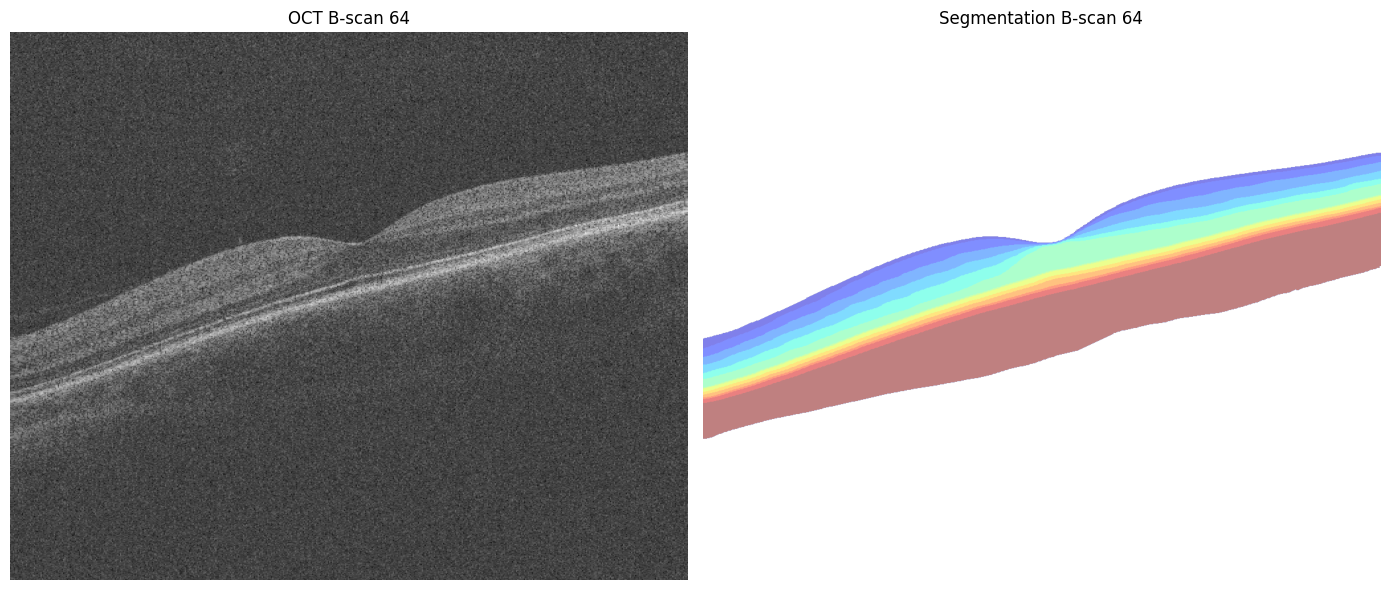

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Select a B-scan index (e.g., central B-scan)
bscan_index = oct_volume.n_bscans // 2

# Plot the OCT B-scan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot OCT B-scan
oct_volume.plot_bscan(bscan_index, ax=axes[0])
axes[0].set_title(f'OCT B-scan {bscan_index}')

# Plot segmentation for the same B-scan
segmentation.plot_bscan(bscan_index, ax=axes[1])
axes[1].set_title(f'Segmentation B-scan {bscan_index}')

plt.tight_layout()
plt.show()


## 7. Plotting Enface Image

Visualize the enface projection of the OCT volume.


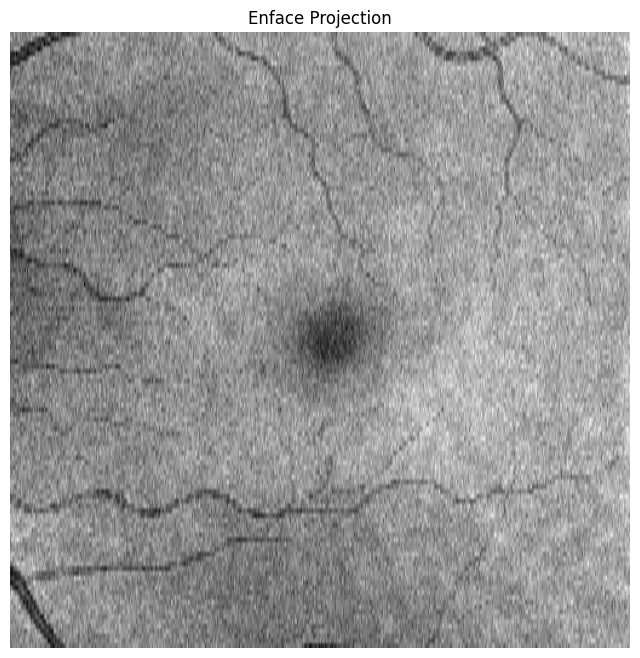

In [34]:
# Plot enface image
fig, ax = plt.subplots(figsize=(8, 8))
oct_volume.plot_enface_image(ax=ax)
ax.set_title('Enface Projection')
plt.show()


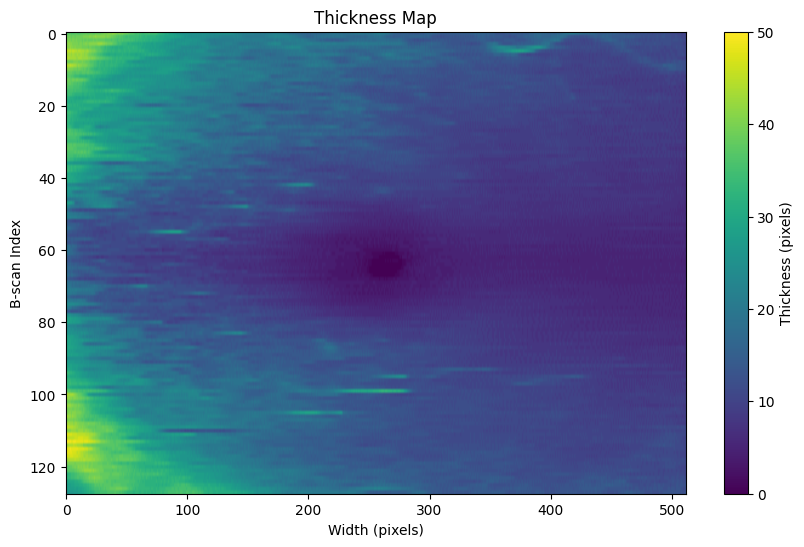

In [35]:
# Example: Extract a specific layer (if available in labels)
# Note: Layer names depend on the segmentation model used
labelname = 'Retinal Nerve Fiber Layer (RNFL)'
if labelname in segmentation.LABELS:
    label_value = segmentation.LABELS[labelname]
    layer_mask = (segmentation.data == label_value)
    
    # Get thickness map for this layer (sum along depth axis)
    thickness_map = np.sum(layer_mask, axis=1)
    
    # Visualize thickness map
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(thickness_map, cmap='viridis', aspect='auto')
    ax.set_title('Thickness Map')
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('B-scan Index')
    plt.colorbar(ax.images[0], ax=ax, label='Thickness (pixels)')
    plt.show()
else:
    print("RNFL layer not found in segmentation labels")
    print(f"Available layers: {list(segmentation.LABELS.keys())}")




## 8. Using RetinalThicknessReport

The `RetinalThicknessReport` class provides comprehensive thickness analysis with ETDRS grid measurements. It can work with both `ContoursData` (height maps) and `PixelWiseSegmentation` (pixel-wise labels). The conversion from pixel-wise to height maps is handled automatically.

### Method 1: Direct Usage with PixelWiseSegmentation (Simplest)

The easiest way is to use `RetinalThicknessReport.from_pixelwise()` which handles conversion and fovea detection automatically.



### Using from_pixelwise() Method

This method automatically converts PixelWiseSegmentation to ContoursData and can optionally find the fovea location.


In [36]:
from rtnls_oct import reporting
from importlib import reload
reload(reporting)

# Create report directly from PixelWiseSegmentation
# This uses PixelWiseSegmentation natively and finds the fovea automatically
report = reporting.RetinalThicknessReport.from_pixelwise(
    oct_volume=oct_volume,
    pixel_seg=segmentation,
    laterality=oct_volume.laterality,
    auto_find_fovea=True  # Automatically detect fovea location
)

print(f"Report created successfully!")
print(f"Available layers: {list(report.segmentation.LABELS.keys())}")
print(f"Fovea location: y={report.fovea_y:.1f}, x={report.fovea_x:.1f} pixels")


Using layers for fovea detection:  ['Retinal Nerve Fiber Layer (RNFL)', 'Ganglion cell layer (GCL)', 'Inner plexiform layer (IPL)', 'Inner nuclear layer (INL)', 'Outer plexiform layer (OPL)', 'Outer nuclear layer (ONL)', 'External limiting membrane (ELM)', 'Myoid zone (MZ)', 'Ellipsoid zone (EZ)', 'Outer Segments (OS)', 'Inter Digitation Zone (IDZ)', 'Retinal pigment epithelium (RPE)', 'Other']
Fovea found at: 63.86886632825719, 264.0160744500846
Report created successfully!
Available layers: ['background', 'Retinal Nerve Fiber Layer (RNFL)', 'Ganglion cell layer (GCL)', 'Inner plexiform layer (IPL)', 'Inner nuclear layer (INL)', 'Outer plexiform layer (OPL)', 'Outer nuclear layer (ONL)', 'External limiting membrane (ELM)', 'Myoid zone (MZ)', 'Ellipsoid zone (EZ)', 'Outer Segments (OS)', 'Inter Digitation Zone (IDZ)', 'Retinal pigment epithelium (RPE)', 'Choroid', 'Other']
Fovea location: y=63.9, x=264.0 pixels


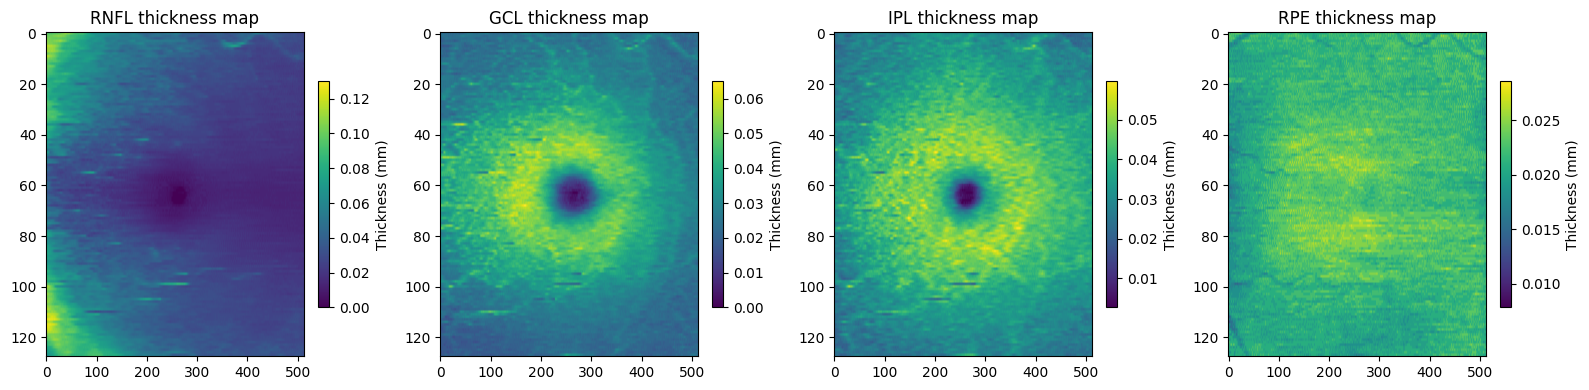

In [37]:
# Visualize thickness maps for a few selected retinal layers
# Note: With PixelWiseSegmentation, we calculate thickness by summing pixels along depth axis
import matplotlib.pyplot as plt
import numpy as np

# Map standard layer names to actual layer names in the segmentation
layer_mapping = {
    'RNFL': 'Retinal Nerve Fiber Layer (RNFL)',
    'GCL': 'Ganglion cell layer (GCL)',
    'IPL': 'Inner plexiform layer (IPL)',
    'INL': 'Inner nuclear layer (INL)',
    'OPL': 'Outer plexiform layer (OPL)',
    'ONL': 'Outer nuclear layer (ONL)',
    'RPE': 'Retinal pigment epithelium (RPE)'
}

selected_layers = ['RNFL', 'GCL', 'IPL', 'RPE']
available_layers = [l for l in selected_layers if l in layer_mapping and layer_mapping[l] in segmentation.LABELS]
n_layers = len(available_layers)

if n_layers > 0:
    fig, axes = plt.subplots(1, n_layers, figsize=(4 * n_layers, 4))
    if n_layers == 1:
        axes = [axes]
    
    for i, layer in enumerate(available_layers):
        layer_name = layer_mapping[layer]
        label_value = segmentation.LABELS[layer_name]
        layer_mask = (segmentation.data == label_value)
        # Sum along depth axis to get thickness map
        thickness_map = np.sum(layer_mask, axis=1) * oct_volume.res_height_mm  # Convert to mm
        
        ax = axes[i]
        im = ax.imshow(thickness_map, cmap='viridis', aspect='auto')
        ax.set_title(f"{layer} thickness map")
        plt.colorbar(im, ax=ax, fraction=0.04, label='Thickness (mm)')
    
    plt.tight_layout()
    plt.show()
else:
    print("No selected layers found in segmentation")


### Finding Fovea Location

The RetinalThicknessReport requires the fovea location. We can use the `find_fovea` utility function to automatically detect it from the ILM height map.


In [38]:
# The report already has the fovea location from the previous step
print(f"Using fovea location: y={report.fovea_y:.1f}, x={report.fovea_x:.1f} pixels")


Using fovea location: y=63.9, x=264.0 pixels


### Creating and Configuring RetinalThicknessReport

Now we create a RetinalThicknessReport and add thickness maps to analyze. Common thickness maps include:
- **RNFL**: Retinal Nerve Fiber Layer (ILM to RNFL)
- **GCL+IPL**: Ganglion Cell and Inner Plexiform Layers
- **Total Retina**: Total retinal thickness (ILM to RPE)


In [39]:
# Add thickness maps to the report
# Note: With PixelWiseSegmentation, we use layer_names (list of layer names)
#       Thickness is calculated by summing pixels along depth axis for these layers

# Map standard layer names to actual layer names in the segmentation
available_labels = segmentation.LABELS.keys()

# Total Retina: Sum all retinal layers (RNFL to RPE)
total_layers = [
    'Retinal Nerve Fiber Layer (RNFL)',
    'Ganglion cell layer (GCL)',
    'Inner plexiform layer (IPL)',
    'Inner nuclear layer (INL)',
    'Outer plexiform layer (OPL)',
    'Outer nuclear layer (ONL)',
    'External limiting membrane (ELM)',
    'Myoid zone (MZ)',
    'Ellipsoid zone (EZ)',
    'Outer Segments (OS)',
    'Inter Digitation Zone (IDZ)',
    'Retinal pigment epithelium (RPE)'
]
total_layers = [l for l in total_layers if l in available_labels]
if len(total_layers) > 0:
    report.add_thickness_map(
        name="Total",
        layer_names=total_layers,
        vmin=0,
        vmax=0.5  # Maximum thickness in mm
    )

# RNFL: Retinal Nerve Fiber Layer
if 'Retinal Nerve Fiber Layer (RNFL)' in available_labels:
    report.add_thickness_map(
        name="RNFL",
        layer_names=['Retinal Nerve Fiber Layer (RNFL)'],
        vmin=0,
        vmax=0.2  # Maximum thickness in mm
    )

# GCL+IPL: Combined ganglion cell and inner plexiform layers
gcl_ipl_layers = []
if 'Ganglion cell layer (GCL)' in available_labels:
    gcl_ipl_layers.append('Ganglion cell layer (GCL)')
if 'Inner plexiform layer (IPL)' in available_labels:
    gcl_ipl_layers.append('Inner plexiform layer (IPL)')
if len(gcl_ipl_layers) > 0:
    report.add_thickness_map(
        name="GCL_IPL",
        layer_names=gcl_ipl_layers,
        vmin=0,
        vmax=0.15  # Maximum thickness in mm
    )

# Inner Retina: RNFL, GCL, IPL, INL
inner_retina_layers = []
for layer in ['Retinal Nerve Fiber Layer (RNFL)', 'Ganglion cell layer (GCL)', 
              'Inner plexiform layer (IPL)', 'Inner nuclear layer (INL)']:
    if layer in available_labels:
        inner_retina_layers.append(layer)
if len(inner_retina_layers) > 0:
    report.add_thickness_map(
        name="Inner_Retina",
        layer_names=inner_retina_layers,
        vmin=0,
        vmax=0.4  # Maximum thickness in mm
    )

print(f"Added {len(report.thickness_maps)} thickness maps to report")
print(f"Thickness maps: {list(report.thickness_maps.keys())}")


Added 4 thickness maps to report
Thickness maps: ['Total', 'RNFL', 'GCL_IPL', 'Inner_Retina']


### Processing the Report

Process all thickness maps to calculate ETDRS grid measurements, thickness maps, and quality metrics.


In [40]:
# Process all thickness maps
report.process()

print("Processing complete!")
print(f"Processed {len(report.thickness_maps)} thickness maps")


Processing complete!
Processed 4 thickness maps


### Getting Quantitative Results

Extract quantitative measurements from the ETDRS grid regions.


In [41]:
# Get quantitative results
results = report.get_result_dict()

# Display some key results
print("ETDRS Grid Measurements (mean thickness in mm):")
print("=" * 60)

for mapname in report.thickness_maps.keys():
    print(f"\n{mapname}:")
    print("-" * 40)
    
    # Central circle (C0)
    c0_key = f'{mapname}_C0_mean'
    if c0_key in results and results[c0_key] is not None:
        print(f"  Central (C0): {results[c0_key]:.3f} mm")
    
    # Inner ring quadrants
    for quadrant in ['S1', 'I1', 'N1', 'T1']:
        key = f'{mapname}_{quadrant}_mean'
        if key in results and results[key] is not None:
            print(f"  {quadrant}: {results[key]:.3f} mm")
    
    # Outer ring quadrants
    for quadrant in ['S2', 'I2', 'N2', 'T2']:
        key = f'{mapname}_{quadrant}_mean'
        if key in results and results[key] is not None:
            print(f"  {quadrant}: {results[key]:.3f} mm")

# Display all results as a dictionary
print("\n" + "=" * 60)
print("Complete results dictionary:")
print(f"Total measurements: {len(results)}")


ETDRS Grid Measurements (mean thickness in mm):

Total:
----------------------------------------
  Central (C0): 0.278 mm
  S1: 0.337 mm
  I1: 0.333 mm
  N1: 0.340 mm
  T1: 0.324 mm
  S2: 0.292 mm
  I2: 0.273 mm
  N2: 0.306 mm
  T2: 0.273 mm

RNFL:
----------------------------------------
  Central (C0): 0.008 mm
  S1: 0.025 mm
  I1: 0.027 mm
  N1: 0.020 mm
  T1: 0.016 mm
  S2: 0.036 mm
  I2: 0.037 mm
  N2: 0.039 mm
  T2: 0.019 mm

GCL_IPL:
----------------------------------------
  Central (C0): 0.043 mm
  S1: 0.098 mm
  I1: 0.094 mm
  N1: 0.098 mm
  T1: 0.093 mm
  S2: 0.069 mm
  I2: 0.064 mm
  N2: 0.080 mm
  T2: 0.073 mm

Inner_Retina:
----------------------------------------
  Central (C0): 0.073 mm
  S1: 0.161 mm
  I1: 0.163 mm
  N1: 0.164 mm
  T1: 0.147 mm
  S2: 0.134 mm
  I2: 0.128 mm
  N2: 0.156 mm
  T2: 0.122 mm

Complete results dictionary:
Total measurements: 160


### Visualizing Thickness Maps

Visualize the thickness maps with ETDRS grid overlays.



Plotting Total thickness map...


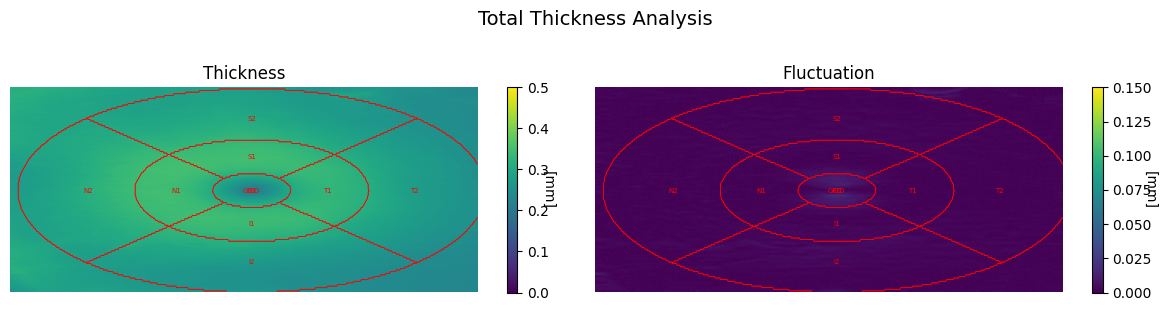


Plotting RNFL thickness map...


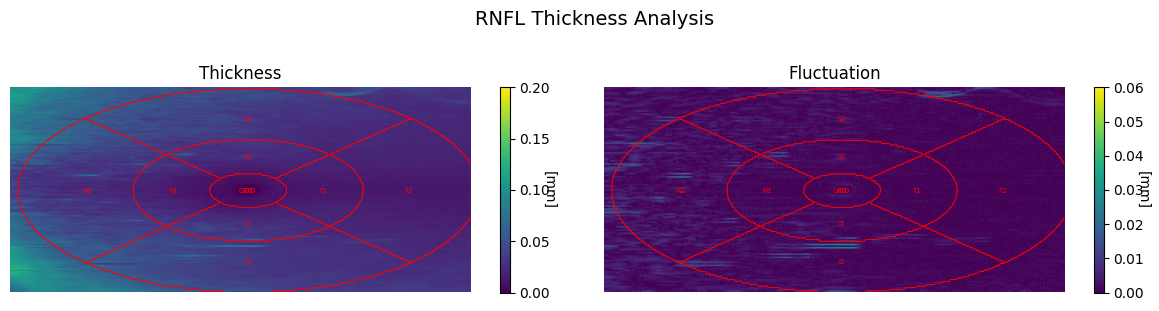


Plotting GCL_IPL thickness map...


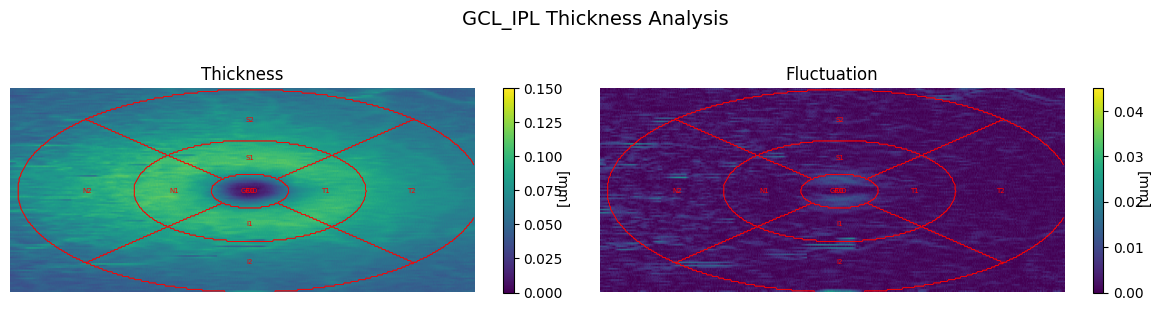


Plotting Inner_Retina thickness map...


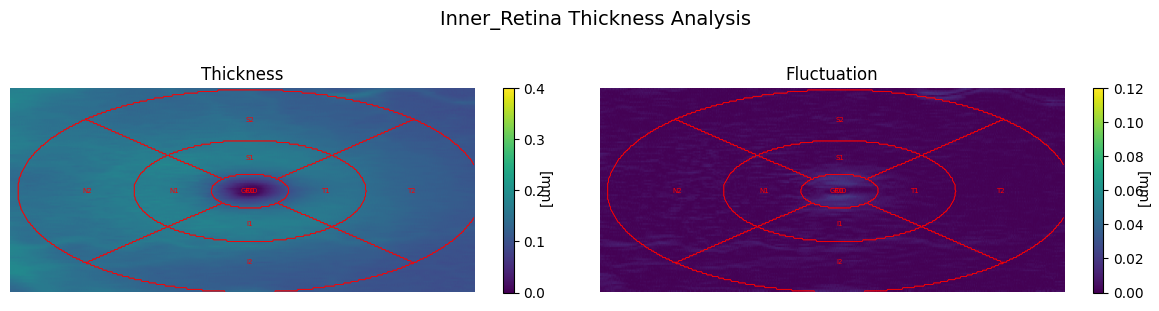

In [42]:
# Plot results for each thickness map
for mapname in report.thickness_maps.keys():
    print(f"\nPlotting {mapname} thickness map...")
    fig, axes = report.plot_results(mapname)
    plt.suptitle(f'{mapname} Thickness Analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### Generating HTML Report

Generate a comprehensive HTML report with all visualizations and measurements.


In [43]:
import os

# Create output directory for report
output_dir = './output/report'
os.makedirs(output_dir, exist_ok=True)

# Generate HTML report
report.write_report_html(
    file_path=output_dir,
    id=f'instance_{instanceid}'
)

print(f"HTML report generated at: {output_dir}/report.html")
print(f"Open the report in a web browser to view all results")


HTML report generated at: ./output/report/report.html
Open the report in a web browser to view all results


### Accessing Individual Thickness Maps

You can also access the processed thickness maps directly for custom analysis.


In [44]:
# Access individual thickness maps
for mapname, mapdata in report.thickness_maps.items():
    print(f"\n{mapname}:")
    print(f"  Thickness map shape: {mapdata.thickness.shape}")
    print(f"  Mean thickness: {np.mean(mapdata.thickness):.3f} mm")
    print(f"  Min thickness: {np.min(mapdata.thickness):.3f} mm")
    print(f"  Max thickness: {np.max(mapdata.thickness):.3f} mm")
    print(f"  Mean fluctuation: {np.mean(mapdata.fluctuation_map):.3f} mm")
    
    # Access ETDRS grid masks
    print(f"  ETDRS grid fields: {list(mapdata.etdrs_grid.keys())}")
    
    # Example: Get thickness in central circle
    if 'C0' in mapdata.etdrs_grid:
        c0_mask = mapdata.etdrs_grid['C0']
        c0_thickness = np.mean(mapdata.thickness[c0_mask])
        print(f"  Central circle (C0) mean: {c0_thickness:.3f} mm")



Total:
  Thickness map shape: (128, 512)
  Mean thickness: 0.291 mm
  Min thickness: 0.216 mm
  Max thickness: 0.354 mm
  Mean fluctuation: 0.002 mm
  ETDRS grid fields: ['C0', 'GRID', 'S1', 'I1', 'N1', 'T1', 'S2', 'I2', 'N2', 'T2']
  Central circle (C0) mean: 0.278 mm

RNFL:
  Thickness map shape: (128, 512)
  Mean thickness: 0.035 mm
  Min thickness: 0.000 mm
  Max thickness: 0.130 mm
  Mean fluctuation: 0.002 mm
  ETDRS grid fields: ['C0', 'GRID', 'S1', 'I1', 'N1', 'T1', 'S2', 'I2', 'N2', 'T2']
  Central circle (C0) mean: 0.008 mm

GCL_IPL:
  Thickness map shape: (128, 512)
  Mean thickness: 0.071 mm
  Min thickness: 0.003 mm
  Max thickness: 0.117 mm
  Mean fluctuation: 0.002 mm
  ETDRS grid fields: ['C0', 'GRID', 'S1', 'I1', 'N1', 'T1', 'S2', 'I2', 'N2', 'T2']
  Central circle (C0) mean: 0.043 mm

Inner_Retina:
  Thickness map shape: (128, 512)
  Mean thickness: 0.137 mm
  Min thickness: 0.003 mm
  Max thickness: 0.190 mm
  Mean fluctuation: 0.002 mm
  ETDRS grid fields: ['C0', '

## Summary

This notebook demonstrated:

1. **Setting up database connection** - Connecting to eyened_orm database
2. **Querying for OCT data** - Finding OCT images with segmentations
3. **Loading OCT volumes** - Converting ImageInstance to OCT3DVolume
4. **Loading segmentations** - Converting ModelSegmentation to PixelWiseSegmentation
5. **Visualizing data** - Plotting B-scans and enface images
6. **Working with layers** - Extracting and analyzing specific retinal layers

The loaded `OCT3DVolume` and `PixelWiseSegmentation` objects can now be used with other Retinalysis-OCT analysis tools such as:
- `RetinalThicknessReport` (after converting to ContoursData)
- ETDRS grid analysis
- Fovea localization
- Quality metrics
- PCA analysis

For more information, see the [eyened dataloading documentation](../eyened/README.md).
